# Previsão de Demanda: Planejamento de Estoque (Questão 7)

Nesta etapa, o objetivo é prever quantas unidades do "Motor de Popa" serão vendidas na primeira semana de 2024. Usamos uma lógica de Baseline para ajudar o Sr. Almir a não deixar o produto faltar no estoque.

---

### 1. Setup e Preparação das Séries Temporais
Carregamento dos dados de vendas e produtos, garantindo que as datas estejam no formato correto. Filtramos apenas as vendas do Motor de Popa para criar a nossa série temporal de treino (2023) e teste (2024).

In [1]:
import pandas as pd
import sys
from pathlib import Path
import plotly.graph_objects as go
from sklearn.metrics import mean_absolute_error

BASE_DIR = Path.cwd().parent

if str(BASE_DIR) not in sys.path:
    sys.path.append(str(BASE_DIR))

from src.utils.data_loader import load_datasets

dfs = load_datasets(["vendas_2023_2024.csv"], layer="raw")
dfs.update(load_datasets(["produtos_processed.csv"]))

df_sales = dfs["vendas_2023_2024.csv"]
df_products = dfs["produtos_processed.csv"]

df_sales["sale_date"] = pd.to_datetime(
    df_sales["sale_date"], format="mixed", dayfirst=True
).dt.date

### Engenharia de Features e Modelo Baseline

Como a demanda pode variar muito de um dia para o outro, criamos uma **Média Móvel de 7 dias**. Essa técnica suaviza os picos e vales, criando uma previsão mais realista baseada no comportamento recente de vendas.

In [2]:
target_product_name = "Evo Dash 155HP"
target_product = df_products[
    df_products["name"].str.contains(target_product_name, case=False, na=False)
]
target_id = target_product["code"].iloc[0]

df_target = df_sales[df_sales["id_product"] == target_id].copy()
df_sales_per_day = df_target.groupby("sale_date")["qtd"].sum().reset_index()

data_min = pd.to_datetime("2023-01-01").date()
data_max = pd.to_datetime("2024-01-31").date()
calendar = pd.DataFrame({"sale_date": pd.date_range(start=data_min, end=data_max).date})

df_model = calendar.merge(df_sales_per_day, on="sale_date", how="left").fillna(0)
df_model["baseline_pred_7d"] = df_model["qtd"].rolling(window=7).mean().shift(1)

mask_trainning = df_model["sale_date"] <= pd.to_datetime("2023-12-31").date()
mask_test = (df_model["sale_date"] >= pd.to_datetime("2024-01-01").date()) & (
    df_model["sale_date"] <= pd.to_datetime("2024-01-31").date()
)

df_trainning = df_model[mask_trainning].copy()
df_test = df_model[mask_test].copy()

df_test["absolute_error"] = (df_test["qtd"] - df_test["baseline_pred_7d"]).abs()
mae = df_test["absolute_error"].mean()

df_presentation = df_test[['sale_date', 'qtd', 'baseline_pred_7d']].head(10).copy()
df_presentation.rename(columns={
    'sale_date': 'Data',
    'qtd': 'Vendas Reais (Unidades)',
    'baseline_pred_7d': 'Previsão do Modelo (Média 7d)'
}, inplace=True)

df_presentation['Previsão do Modelo (Média 7d)'] = df_presentation['Previsão do Modelo (Média 7d)'].round(2)

print("=== RESULTADO DA MODELAGEM (BASELINE) ===")
print(f"Produto Alvo: Motor de Popa Yamaha Evo Dash 155HP (ID: {target_id})")
print(f"Período de Teste: {df_test['sale_date'].min().strftime('%d/%m/%Y')} a {df_test['sale_date'].max().strftime('%d/%m/%Y')}")
print(f"Métrica MAE: O modelo erra, em média, {mae:.2f} unidades por dia.")
print("=========================================\n")

print("Amostra das previsões geradas para o Início de Janeiro/2024:")
print(df_presentation.to_string(index=False))

=== RESULTADO DA MODELAGEM (BASELINE) ===
Produto Alvo: Motor de Popa Yamaha Evo Dash 155HP (ID: 54)
Período de Teste: 01/01/2024 a 31/01/2024
Métrica MAE: O modelo erra, em média, 1.64 unidades por dia.

Amostra das previsões geradas para o Início de Janeiro/2024:
      Data  Vendas Reais (Unidades)  Previsão do Modelo (Média 7d)
2024-01-01                      0.0                           0.00
2024-01-02                      0.0                           0.00
2024-01-03                      0.0                           0.00
2024-01-04                      0.0                           0.00
2024-01-05                     10.0                           0.00
2024-01-06                      0.0                           1.43
2024-01-07                      0.0                           1.43
2024-01-08                      0.0                           1.43
2024-01-09                      0.0                           1.43
2024-01-10                      0.0                           1.

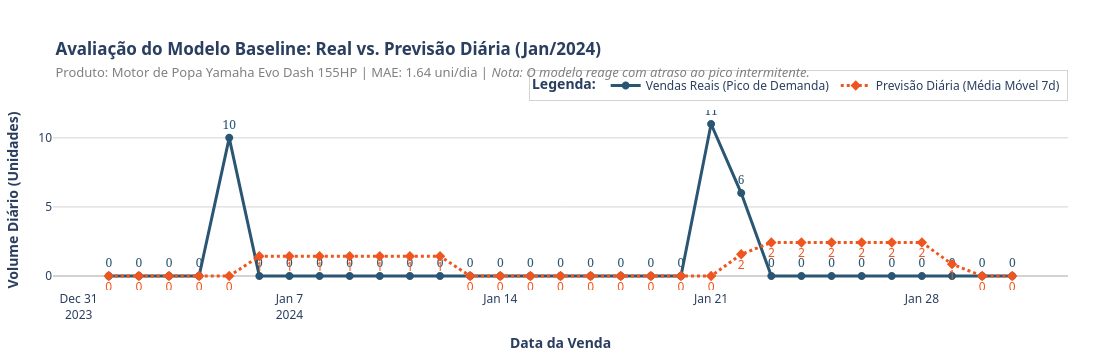

In [3]:
# ==========================================
# VISUALIZATION
# ==========================================

df_viz = df_test[df_test['sale_date'].astype(str).str.startswith('2024-01')].copy()

df_viz['display_pred'] = df_viz['baseline_pred_7d'].round(0)

df_mae = df_viz.dropna(subset=['baseline_pred_7d'])
mae = mean_absolute_error(df_mae['qtd'], df_mae['baseline_pred_7d'])

fig_forecast = go.Figure()

fig_forecast.add_trace(go.Scatter(
    x=df_viz['sale_date'],
    y=df_viz['qtd'],
    name="Vendas Reais (Pico de Demanda)",
    line=dict(color='#2A5674', width=3),
    mode='lines+markers+text',
    text=df_viz['qtd'],
    textposition="top center",
    textfont=dict(color='#2A5674', size=12, family="Arial Black"),
    marker=dict(size=8)
))

fig_forecast.add_trace(go.Scatter(
    x=df_viz['sale_date'],
    y=df_viz['baseline_pred_7d'],
    name="Previsão Diária (Média Móvel 7d)",
    line=dict(color='#EF551E', width=3, dash='dot'),
    mode='lines+markers+text',
    text=df_viz['display_pred'], 
    texttemplate='%{text:.0f}',
    textposition="bottom center",
    textfont=dict(color='#EF551E', size=12),
    marker=dict(symbol='diamond', size=8)
))

target_product_name = target_product['name'].iloc[0]

fig_forecast.update_layout(
    title=f"<b>Avaliação do Modelo Baseline: Real vs. Previsão Diária (Jan/2024)</b><br>" +
          f"<span style='font-size:13px; color:gray;'>Produto: {target_product_name} | MAE: {mae:.2f} uni/dia | <i>Nota: O modelo reage com atraso ao pico intermitente.</i></span>",
    xaxis_title="<b>Data da Venda</b>",
    yaxis_title="<b>Volume Diário (Unidades)</b>",
    plot_bgcolor='white',
    hovermode='x unified',
    legend=dict(
        title="<b>Legenda:</b>",
        orientation="h", 
        yanchor="bottom", 
        y=1.05, 
        xanchor="right", 
        x=1,
        bgcolor='rgba(255,255,255,0.9)',
        bordercolor='lightgrey',
        borderwidth=1
    ),
    margin=dict(t=110, b=40, l=40, r=40)
)

fig_forecast.update_yaxes(
    showgrid=True, 
    gridcolor='lightgrey', 
    zeroline=True, 
    zerolinecolor='lightgrey',
    tickformat='d' 
)

fig_forecast.show()

In [4]:


week_start_date = pd.to_datetime('2024-01-01').date()
week_end_date = pd.to_datetime('2024-01-07').date()

first_week_mask = (df_test['sale_date'] >= week_start_date) & (df_test['sale_date'] <= week_end_date)
df_first_week = df_test[first_week_mask]

exact_forecast_sum = df_first_week['baseline_pred_7d'].sum()

rounded_forecast_sum = int(round(exact_forecast_sum))

print("=== RESPOSTA DA VALIDAÇÃO (QUESTÃO 7.2) ===")
print(f"Período analisado: {week_start_date.strftime('%d/%m/%Y')} a {week_end_date.strftime('%d/%m/%Y')}")
print(f"Soma fracionada exata calculada pelo modelo: {exact_forecast_sum:.4f} unidades")
print(f"► Previsão Final de Vendas (Arredondada): {rounded_forecast_sum} unidades")
print("===========================================")

=== RESPOSTA DA VALIDAÇÃO (QUESTÃO 7.2) ===
Período analisado: 01/01/2024 a 07/01/2024
Soma fracionada exata calculada pelo modelo: 2.8571 unidades
► Previsão Final de Vendas (Arredondada): 3 unidades


### Questão 7.3 - Explique:

### Resumo Técnico: Modelo Baseline

**1. Como o baseline foi construído?**

Através de uma Média Móvel de 7 dias aplicada a uma série temporal contínua (com dias sem vendas preenchidos com zero). O modelo assume que a demanda atual é igual à média diária da última semana.

**2. Como evitou data leakage?**

Uso da função `shift(1)`, garantindo que a previsão de "hoje" (D) utilize estritamente os dados consolidados até "ontem" (D-1) e fizemos uma separação rígida entre o treino (até 31/12/2023) e o teste (a partir de 01/01/2024).

**3. Uma limitação do modelo proposto:**

O modelo é puramente reativo, também conhecido como efeito retrovisor. Em produtos de demanda intermitente, ele falha ao não prever picos repentinos (causando ruptura de estoque) e projeta uma "demanda fantasma" irreal nos dias subsequentes ao pico.